# **Emotion Recognition of Twitter Dataset using HuggingFace Transformers**

## What is Transformers


- Transformers are a type of neural network architecture that relies on the attention mechanism. The attention mechanism allows the model to learn long-range dependencies between different parts of a sequence.

- Transformers are typically composed of two main parts: an encoder and a decoder. The encoder takes the input sequence and produces a sequence of hidden states. The decoder then takes these hidden states and produces the output sequence.

- Transformers are now used for a variety of natural language processing tasks, including machine translation, text summarization, and question answering. They have also been used for other tasks, such as speech recognition and computer vision.


##Transformers Architecture

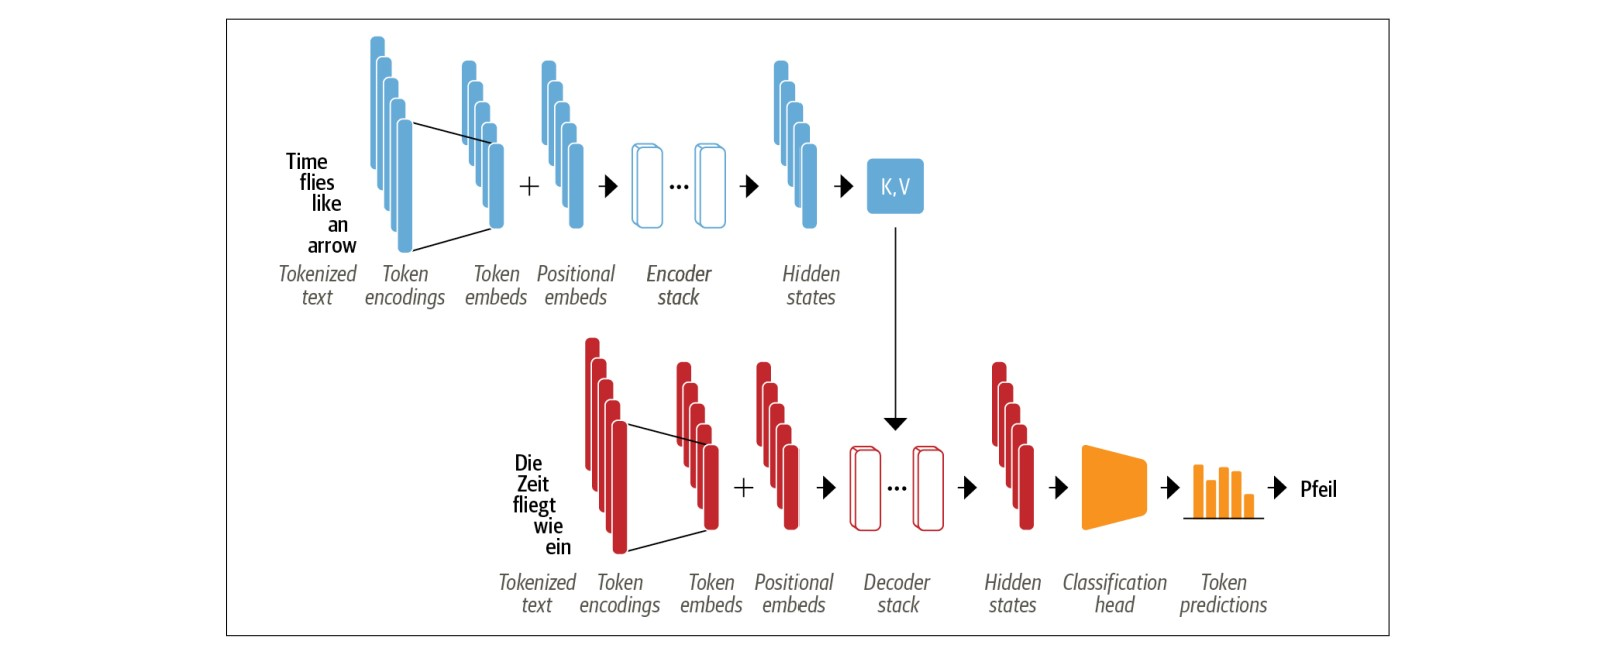

**Tokenized text:**
- The input text is first tokenized, which means that it is broken up into individual words or subwords.

**Token encodings:**
- Each token is then assigned a unique encoding. This encoding represents the meaning of the token and its position in the sequence.

**Token embedding:**
- The token encodings are then passed through a token embedding layer. This layer converts the encodings into a vector representation that can be used by the transformer.

**Positional embedding:**
- The positional embedding layer adds a positional encoding to the token embeddings. This encoding represents the position of each token in the sequence.

**Encode stack:**
- The token embeddings and positional embeddings are then passed through a stack of encoder layers. Each encoder layer applies a self-attention mechanism to the embeddings.
- The self-attention mechanism allows the model to learn long-range dependencies between different parts of the sequence.

**Hidden states:**
- The output of the encoder stack is a sequence of hidden states. These hidden states represent the representation of the input sequence.

**Decoder stack:**
- The hidden states are then passed through a stack of decoder layers. The decoder layers apply a self-attention mechanism and an attention mechanism to the hidden states. The attention mechanism allows the model to attend to different parts of the input sequence when generating the output sequence.


# **Coding**

### **Loading Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report


### **Loading the Dataset**
#### Dataset Summary
Emotion is a dataset of English Twitter messages with six basic emotions: anger, fear, joy, love, sadness, and surprise.


In [3]:
from datasets import load_dataset

emotion = load_dataset('emotion')
emotion.set_format(type='pandas')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
dataset=emotion

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [6]:
dataset['train'][:]

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [7]:
classes = dataset['train'].features['label'].names
classes

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [8]:
label_names = dataset['train']['label'].apply(lambda x: classes[x])
label_name_data=pd.DataFrame(label_names)
label_name_data['names']=pd.DataFrame(label_names)
label_name_data['label']=dataset['train']['label']
label_name_data.value_counts()

,,count
label,names,
1,joy,5362
0,sadness,4666
3,anger,2159
4,fear,1937
2,love,1304
5,surprise,572


- Here we can see that which labels are for which class, just for our reading and understanding

In [9]:
dataset['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

### **Data Analysis**

In [10]:
print('Train shape:', (len(dataset['train']), len(dataset['train'].column_names)))
print('Validation shape:', (len(dataset['validation']), len(dataset['validation'].column_names)))
print('Test shape:', (len(dataset['test']), len(dataset['test'].column_names)))

pd.DataFrame(dataset['train'][:5])

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


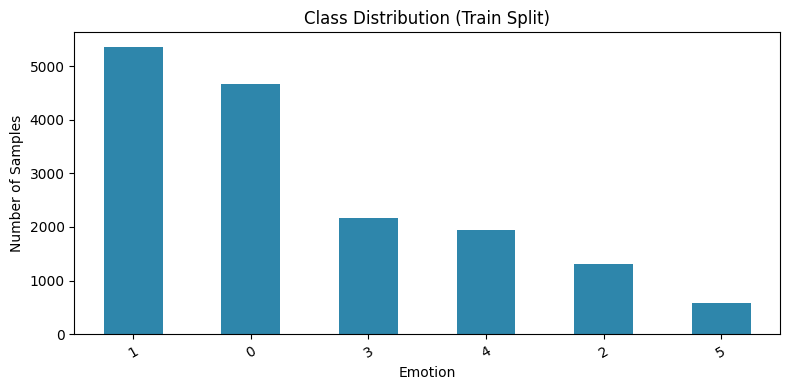

In [11]:


# Class distribution in train split
class_counts = pd.Series(dataset['train']['label']).value_counts().sort_values(ascending=False)
display(class_counts.to_frame('count'))

plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar', color='#2E86AB')
plt.title('Class Distribution (Train Split)')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

- Here we can see that the label 1 means Joy has most count and the dataset is not balanced.

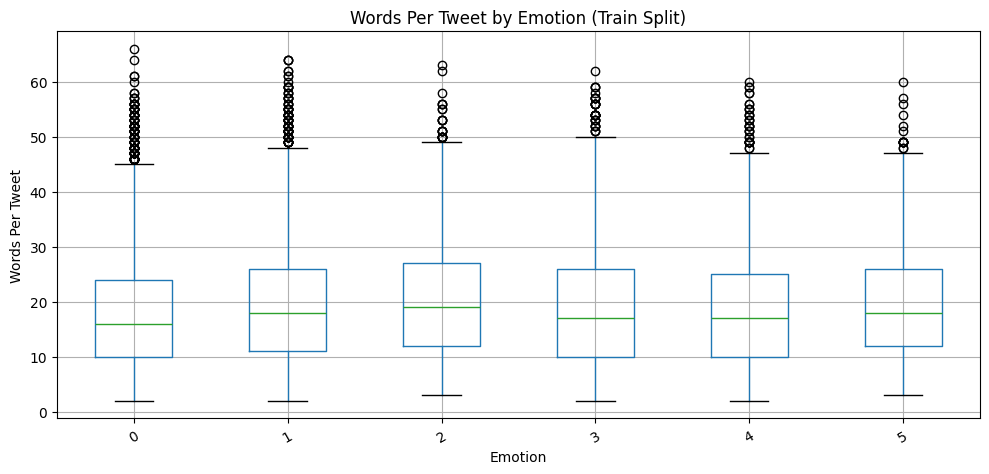

In [12]:

train_word_count = pd.DataFrame({
    'label_name': dataset['train']['label'],
    'Words Per Tweet': [len(str(t).split()) for t in dataset['train']['text']]
})

train_word_count.boxplot('Words Per Tweet', by='label_name', figsize=(10, 5))
plt.title('Words Per Tweet by Emotion (Train Split)')
plt.suptitle('')
plt.xlabel('Emotion')
plt.ylabel('Words Per Tweet')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

- Seeing the Boxplot we can see that most of the classes have max 64 words and most have mean of 20 words approximately

## **Text Preprocessing**

Text preprocessing is often unnecessary because pretrained transformers like Roberta:

- Are pretrained on diverse, raw text: They've learned from real-world language variations.

- Use subword tokenization: This handles unknown words and variations without explicit cleaning.

- Generate contextual embeddings: They understand word meanings based on surrounding text, accommodating different forms.

## **BERT and RoBERTa**

### **BERT (Bidirectional Encoder Representations from Transformers):**

Core Idea: Pre-trained deep learning model for natural language processing, using a transformer architecture.
- Pre-training Tasks: Trained on Masked Language Modeling (MLM) and Next Sentence Prediction (NSP).
- Features: Learns bidirectional representations of text, meaning it considers context from both left and right words.
###**RoBERTa (Robustly Optimized BERT Pretraining Approach):**

Core Idea: An optimized version of BERT, not a new architecture, developed by Facebook AI.
Key Optimizations:
- More Data: Trained on a much larger dataset.
- Longer Training: Trained for a longer duration.
- Larger Batch Sizes: Used significantly larger batch sizes during pre-training.
- Dynamic Masking: Masks tokens differently in each training epoch, allowing the model to see a wider variety of masked sequences.
- NSP Removal: Removed the Next Sentence Prediction task, as it was found to be detrimental to downstream performance.

## **Text to Tokens Conversion**
- Transformer models like Roberta cannot receive raw strings as input; instead, they assume the text has been tokenized and encoded as numerical vectors.
- Tokenization is the step of breaking down a string into the atomic units used in the model

In [13]:
from transformers import AutoTokenizer
model_ckpt = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

AutoTokenizer is a powerful class that can automatically load the correct tokenizer for any given pretrained model checkpoint.

 This tokenizer knows how to convert raw text into numerical input IDs that the robeta-base model can understand

In [14]:
text = "I love Machine Learning!. Tokenization is awesome"
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [0, 100, 657, 14969, 13807, 42202, 29464, 1938, 16, 6344, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [15]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)


['<s>', 'I', 'Ġlove', 'ĠMachine', 'ĠLearning', '!.', 'ĠToken', 'ization', 'Ġis', 'Ġawesome', '</s>']


- roberta-base model:  This tokenizer knows:
- - How to split raw text into tokens (words or subword units).
- - The vocabulary (a unique ID for each token) that the roberta-base model understands.
- - Any special tokens (like <s> for start of sequence, </s> for end of sequence, <pad> for padding) specific to the RoBERTa model.

In [16]:
tokenizer.vocab_size, tokenizer.model_max_length

(50265, 512)

# **Tokenization of Emotion Dataset**

In [17]:
dataset.reset_format()

In [18]:
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

df_encoded = dataset.map(tokenize, batched=True,batch_size=None)


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

- tokenize function converts text into a dictionary with:

- - input_ids: Numerical IDs representing each word/subword.
- - attention_mask: Indicates which IDs are actual tokens (1) and which are padding (0).
- - token_type_ids: (Usually all 0s for single sentences) Differentiates between text segments in multi-segment inputs.
- padding=True: This ensures all tokenized sequences within a batch have the same length by adding special [PAD] tokens to shorter sequences. Transformer models require fixed-size input tensors, so padding is essential.

- truncation=True: This handles sequences longer than the model's maximum input length (e.g., 512 tokens for DistilBERT). It truncates longer sequences to fit this limit, preventing errors and managing memory.

In [19]:
print(tokenize(dataset['train'][:2]))

{'input_ids': [[0, 118, 46405, 619, 32386, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 118, 64, 213, 31, 2157, 98, 24418, 7, 98, 37689, 7917, 95, 31, 145, 198, 951, 54, 14534, 8, 16, 24628, 2]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [20]:
df_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## **Fine-Tuning Transformers**

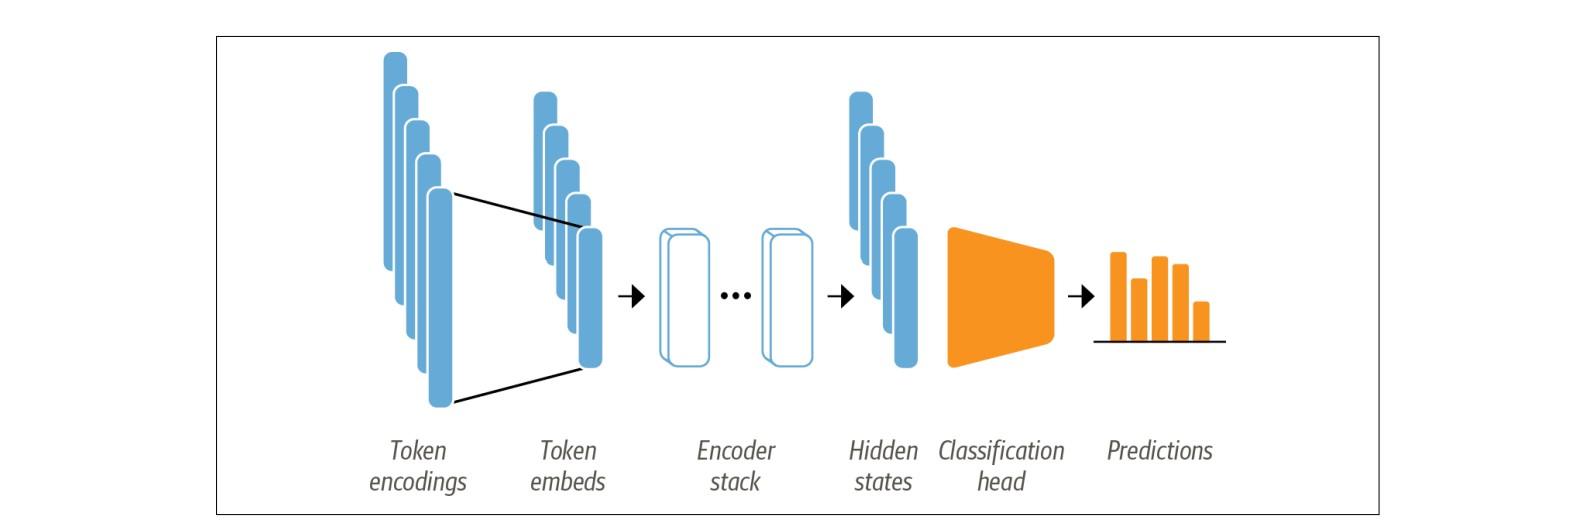

- The AutoModelForSequenceClassification is a class from the Hugging Face Transformers library. Its primary purpose is to load a pre-trained transformer model (like Roberta in this case) and automatically add a classification head on top of its outputs.
- This classification head is a layer (or layers) specifically designed for sequence classification tasks, meaning it takes the contextual embeddings produced by the transformer and outputs predictions for different classes (e.g., emotions).
- This makes it convenient for fine-tuning pre-trained models on classification tasks without manually constructing the classification layers.

In [21]:
from transformers import AutoModelForSequenceClassification

num_labels = len(classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels = num_labels).to(device)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
from transformers import TrainingArguments

batch_size = 64
model_name = "RoBERTa-base-emotion"

training_args = TrainingArguments(
    output_dir = model_name,
    num_train_epochs=2,
    learning_rate = 2e-5,
    per_device_train_batch_size= batch_size,
    per_device_eval_batch_size = batch_size,
    weight_decay=0.01,
    eval_strategy = 'epoch',
    disable_tqdm=False)

- TrainingArguments class from the Hugging Face Transformers library is used to store all the hyperparameters and settings that control the training process.

- as the name for the output directory where the trained model checkpoints and other training artifacts will be saved.

- epochs=2 Sets the total number of training epochs. An epoch means one full pass over the entire training dataset. Here, the model will train for 2 epochs.

- learning_rate = 2e-5: Defines the initial learning rate for the optimizer(default Adam)

- per_device_eval_batch_size = sets the number of samples that will be processed simultaneously during each evaluation step on each available device (e.g., GPU or CPU core).

- weight_decay=0.01: Applies L2 regularization (weight decay) to prevent overfitting

In [23]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}


In [24]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=df_encoded['train'],
    eval_dataset=df_encoded['validation'],
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

- Trainer class is a high-level API from the Hugging Face Transformers library designed to make training and evaluating models straightforward. it has train() for training and eval() for model evaluation

- processing_class=tokenizer: it ensures that if the Trainer needs to do any internal processing that involves tokenization (e.g., for logging or specific callbacks), it uses the correct tokenizer instance.



In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.264914,0.903500,0.904892
2,0.490451,0.197726,0.920500,0.921179


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.4904511108398438, metrics={'train_runtime': 492.7384, 'train_samples_per_second': 64.943, 'train_steps_per_second': 1.015, 'total_flos': 1447162776576000.0, 'train_loss': 0.4904511108398438, 'epoch': 2.0})

## **Prediction**

In [26]:
preds_outputs = trainer.predict(df_encoded['test'])
preds_outputs.metrics

{'test_loss': 0.189900204539299,
 'test_accuracy': 0.9215,
 'test_f1': 0.9223284891968526,
 'test_runtime': 6.2501,
 'test_samples_per_second': 319.995,
 'test_steps_per_second': 5.12}

In [27]:
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = df_encoded['test'][:]['label']

- y_preds takes the model's raw prediction scores (logits) from preds_outputs.predictions. It then uses np.argmax() along axis=1 to find the index of the highest score for each sample, effectively determining the predicted class label.

In [28]:
text = 'Wow, I can\'t believe this just happened!'
input_encoded = tokenizer(text, return_tensors='pt').to(device)
with torch.no_grad():
  outputs = model(**input_encoded)

logits = outputs.logits
pred = torch.argmax(logits, dim=1).item()
pred, classes[pred]

(5, 'surprise')

### **Evaluation**

In [29]:
print("\n--- Training Data Classification Report ---")
train_preds_outputs = trainer.predict(df_encoded['train'])
y_train_preds = np.argmax(train_preds_outputs.predictions, axis=1)
y_train_true = df_encoded['train'][:]['label']
print(classes)
print(classification_report(y_train_true, y_train_preds, target_names=classes))


--- Training Data Classification Report ---


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.97      4666
         joy       0.97      0.93      0.95      5362
        love       0.81      0.93      0.87      1304
       anger       0.93      0.96      0.94      2159
        fear       0.91      0.92      0.91      1937
    surprise       0.81      0.83      0.82       572

    accuracy                           0.94     16000
   macro avg       0.90      0.92      0.91     16000
weighted avg       0.94      0.94      0.94     16000



In [37]:
print("\n--- Validation Data Classification Report ---")
val_preds_outputs = trainer.predict(df_encoded['validation'])
y_val_preds = np.argmax(val_preds_outputs.predictions, axis=1)
y_val_true = df_encoded['validation'][:]['label']
print(classes)
print(classification_report(y_val_true, y_val_preds, target_names=classes))


--- Validation Data Classification Report ---


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
              precision    recall  f1-score   support

     sadness       0.96      0.95      0.95       550
         joy       0.96      0.92      0.94       704
        love       0.80      0.91      0.85       178
       anger       0.92      0.93      0.93       275
        fear       0.86      0.87      0.86       212
    surprise       0.79      0.80      0.80        81

    accuracy                           0.92      2000
   macro avg       0.88      0.90      0.89      2000
weighted avg       0.92      0.92      0.92      2000



In [38]:
print("\n--- Test Data Classification Report ---")
print(classes)
print(classification_report(y_true, y_preds))


--- Test Data Classification Report ---
['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       581
           1       0.96      0.92      0.94       695
           2       0.78      0.88      0.83       159
           3       0.91      0.94      0.92       275
           4       0.87      0.90      0.89       224
           5       0.74      0.76      0.75        66

    accuracy                           0.92      2000
   macro avg       0.87      0.89      0.88      2000
weighted avg       0.92      0.92      0.92      2000



- Based on the Above Classification reports, we can see that how good my model is performing and how generalized it is accross all the clases.


- While i used DistilBERT then it poorly performed in the 5th class and on sample custom input of 5th class it predicted 4th classs, but in case of RoBERTa model it correctly predicted and it outperformed the DistilBERT model

## **Model Saving**

In [39]:
# Save the model and tokenizer to a local directory
model.save_pretrained('emotion_model')
tokenizer.save_pretrained('emotion_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('emotion_model/tokenizer_config.json', 'emotion_model/tokenizer.json')

In [40]:
import shutil

# Name of the directory to be zipped
model_dir = 'emotion_model'

# Name of the zip file
zip_file_name = 'emotion_model_zipped'

# Create a zip archive of the directory
shutil.make_archive(zip_file_name, 'zip', model_dir)

print(f'Model saved to {zip_file_name}.zip')


Model saved to emotion_model_zipped.zip


## Preparing Data for the LLM integration

In [34]:
!pip install -q transformers datasets peft trl bitsandbytes accelerate

In [44]:
from datasets import Dataset
import pandas as pd

train_df_with_preds = dataset['train'].to_pandas()

train_df_with_preds['predicted_label'] = y_train_preds

dataset_with_predictions = Dataset.from_pandas(train_df_with_preds)

print("Dataset with predicted labels created successfully!")
print(dataset_with_predictions)

# Display the first few rows to confirm
display(dataset_with_predictions.to_pandas().head())

Dataset with predicted labels created successfully!
Dataset({
    features: ['text', 'label', 'predicted_label'],
    num_rows: 16000
})


,text,label,predicted_label
0,i didnt feel humiliated,0,0
1,i can go from feeling so hopeless to so damned...,0,0
2,im grabbing a minute to post i feel greedy wrong,3,3
3,i am ever feeling nostalgic about the fireplac...,2,2
4,i am feeling grouchy,3,3


In [46]:
df_to_save_csv = dataset_with_predictions.to_pandas()

csv_file_path = 'emotion_predictions_full.csv'

df_to_save_csv.to_csv(csv_file_path, index=False)

print(f"Dataset with predicted labels saved to {csv_file_path}")

Dataset with predicted labels saved to emotion_predictions_full.csv
